# Task 2.2 — Implementation with Paper References (20 marks)

**Paper**: *Robust Point Set Registration Using Gaussian Mixture Models* — Bing Jian and Baba C. Vemuri, IEEE TPAMI, 2011.

---

## Contribution Being Reproduced

We reproduce the **core registration algorithm** (Algorithm 1 in the paper): non-rigid point set registration using the L2 distance between Gaussian mixtures with TPS-based transformations and multi-scale optimisation. We apply this to our synthetic 2D toy dataset from Task 2.1.

## Evaluation Metric

**Mean Squared Error (MSE)** between the registered model points and the ground-truth deformed model points (scene_clean):
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \|T(m_i) - s_i^{\text{clean}}\|^2$$

This is equivalent to the registration error metric discussed in Section 6 of the paper.

In [1]:
# ============================================================
# Setup: Imports, Random Seed, Load Data
# ============================================================
import numpy as np
from numpy import dot, eye, ones, zeros, trace, r_, c_
from numpy.linalg import svd, norm
from scipy.optimize import fmin_l_bfgs_b
import matplotlib.pyplot as plt
from math import log, exp, sqrt
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs('results', exist_ok=True)

# Load data generated in Task 2.1
model = np.loadtxt('data/model.txt')
scene = np.loadtxt('data/scene.txt')
scene_clean = np.loadtxt('data/scene_clean.txt')

print(f"Model: {model.shape}, Scene: {scene.shape}, Scene clean: {scene_clean.shape}")

Model: (150, 2), Scene: (170, 2), Scene clean: (150, 2)


The cell above loads the model, scene (with noise and outliers), and clean scene (ground truth) generated in Task 2.1. The model has 150 points and the scene has 170 points (150 deformed + 20 outliers).

---

### Step 1: Normalisation

Normalise both point sets to have zero mean and unit variance, as recommended in the author's implementation (`normalize_flag = 1` in the config file). This improves numerical stability of the optimisation.

**Paper reference**: Section 5 (implementation details), also used in the author's `_core.py`.

In [2]:
# ============================================================
# Step 1: Normalisation (Section 5 of the paper)
# ============================================================
def normalize(x):
    """Translate to zero mean, scale to unit variance.
    Returns normalised points, centroid, and scale factor.
    Reference: author's _core.py normalize() function."""
    centroid = x.mean(axis=0)
    x_centered = x - centroid
    scale = norm(x_centered, 'fro') / sqrt(x_centered.shape[0])
    x_normalized = x_centered / scale
    return x_normalized, centroid, scale

def denormalize(x, centroid, scale):
    """Reverse the normalisation."""
    return x * scale + centroid

model_n, c_m, s_m = normalize(model)
scene_n, c_s, s_s = normalize(scene)

print(f"Model centroid: {c_m}, scale: {s_m:.4f}")
print(f"Scene centroid: {c_s}, scale: {s_s:.4f}")
print(f"Model normalised mean: {model_n.mean(0)}, std: {model_n.std():.4f}")

Model centroid: [7.40148683e-19 1.33333333e-08], scale: 1.0223
Scene centroid: [ 0.04180307 -0.007887  ], scale: 1.0672
Model normalised mean: [-3.92278802e-17  2.80331314e-17], std: 0.7071


The normalisation centres each point set at the origin and scales it so that the Frobenius norm divided by $\sqrt{N}$ equals 1. This ensures the scale parameter $\sigma$ in the Gaussian mixtures has a consistent meaning across datasets.

---

### Step 2: Gauss Transform (L2 Distance Computation)

The core computation is the **Gauss transform**: given two point sets $A$ and $B$ and scale $\sigma$, compute:
$$f(A, B, \sigma) = \sum_i \sum_j \phi(a_i - b_j | 0, 2\sigma^2 I)$$
and its gradient with respect to $A$. This is used to evaluate the L2 distance between the two GMMs.

**Paper reference**: Equation 4 — $\int \phi(x|\mu_1, \Sigma_1) \phi(x|\mu_2, \Sigma_2) dx = \phi(0 | \mu_1 - \mu_2, \Sigma_1 + \Sigma_2)$

In [3]:
# ============================================================
# Step 2: Gauss Transform (Equation 4, Section 3)
# ============================================================
def gauss_transform(A, B, scale):
    """
    Compute the Gauss transform between two point sets:
      f = sum_i sum_j exp(-||a_i - b_j||^2 / (2*scale^2))
    and the gradient of f w.r.t. A.
    
    This implements the closed-form integral of the product of
    two Gaussians (Eq. 4 in the paper).
    
    Reference: Equation 4, Section 3 of Jian & Vemuri PAMI'11.
    Also: author's c_extension/gauss_transform.py
    """
    n_a, d = A.shape
    n_b = B.shape[0]
    
    f = 0.0
    grad = np.zeros_like(A)
    
    for i in range(n_a):
        for j in range(n_b):
            diff = A[i] - B[j]
            dist_sq = np.sum(diff ** 2)
            cost = np.exp(-dist_sq / (2.0 * scale * scale))
            f += cost
            grad[i] -= cost * diff / (scale * scale)
    
    return f, grad


def L2_distance(model_pts, scene_pts, scale):
    """
    Compute the L2 distance between two Gaussian mixtures:
      d_L2 = int (f(x) - g(x))^2 dx
            = int f^2 dx - 2 int f*g dx + int g^2 dx
    Since g (scene) is fixed, we only compute the first two terms.
    Returns the distance and gradient w.r.t. model.
    
    Reference: Equation 5, Section 3 of Jian & Vemuri PAMI'11.
    Also: author's _core.py L2_distance() function.
    """
    f1, g1 = gauss_transform(model_pts, model_pts, scale)
    f2, g2 = gauss_transform(model_pts, scene_pts, scale)
    f = f1 - 2 * f2
    g = 2 * g1 - 2 * g2
    return f, g

# Quick test
test_f, test_g = L2_distance(model_n[:5], scene_n[:5], 0.5)
print(f"L2 distance test (5 points each, sigma=0.5): f={test_f:.4f}")
print(f"Gradient shape: {test_g.shape}")

L2 distance test (5 points each, sigma=0.5): f=-23.0280
Gradient shape: (5, 2)


The `gauss_transform` function computes $\sum_i \sum_j \exp(-\|a_i - b_j\|^2 / 2\sigma^2)$, which is the closed-form integral of the product of two Gaussian mixtures (Eq. 4). The `L2_distance` function then combines two Gauss transforms — model-model and model-scene — to compute the L2 distance (Eq. 5), dropping the constant scene-scene term.

---

### Step 3: Thin-Plate Spline (TPS) Basis Computation

Construct the TPS kernel matrix and basis for non-rigid transformation.

**Paper reference**: Section 5, discussion of TPS kernel $K(r) = r^2 \log r$ for 2D.

In [4]:
# ============================================================
# Step 3: TPS Kernel and Basis (Section 5, Eq. 16-17)
# ============================================================
def tps_kernel_2d(r):
    """TPS radial basis function for 2D: K(r) = r^2 * log(r).
    Reference: Section 5, paragraph on TPS kernels."""
    if r == 0:
        return 0.0
    return r * r * log(r)


def compute_TPS_K(ctrl_pts, landmarks=None):
    """Compute the TPS kernel matrix K and (optionally) the evaluation matrix U.
    Reference: author's _core.py compute_TPS_K()."""
    n, d = ctrl_pts.shape
    K = np.array([tps_kernel_2d(norm(ctrl_pts[i] - ctrl_pts[j]))
                  for i in range(n) for j in range(n)]).reshape(n, n)
    if landmarks is not None:
        m = landmarks.shape[0]
        U = np.array([tps_kernel_2d(norm(landmarks[i] - ctrl_pts[j]))
                      for i in range(m) for j in range(n)]).reshape(m, n)
    else:
        U = None
    return K, U


def prepare_TPS_basis(landmarks, ctrl_pts):
    """Prepare the TPS basis matrix and kernel for bending energy.
    
    The basis matrix maps the parameter vector to transformed points.
    The kernel matrix is used to compute the bending energy regulariser.
    
    Reference: Section 5 of the paper; author's _core.py prepare_TPS_basis()."""
    m, d = landmarks.shape
    n = ctrl_pts.shape[0]
    K, U = compute_TPS_K(ctrl_pts, landmarks)
    
    # Polynomial part: [1, x, y] for 2D
    Pm = c_[ones((m, 1)), landmarks]     # m x (d+1)
    Pn = c_[ones((n, 1)), ctrl_pts]      # n x (d+1)
    
    # SVD-based projection to enforce TPS constraints
    u, s, vh = svd(Pn)
    PP = u[:, d+1:]                       # n x (n-d-1)
    
    TPS_basis = c_[Pm, dot(U, PP)]        # m x n
    TPS_kernel = dot(PP.T, dot(K, PP))    # (n-d-1) x (n-d-1)
    
    return TPS_basis, TPS_kernel


# Use model as control points (same as author's default)
ctrl_pts_n = model_n.copy()
basis, kernel = prepare_TPS_basis(model_n, ctrl_pts_n)

print(f"TPS basis shape: {basis.shape}")
print(f"TPS kernel shape: {kernel.shape}")

TPS basis shape: (150, 150)
TPS kernel shape: (147, 147)


The TPS basis matrix maps the $(d+1) + (n-d-1) = n$ dimensional parameter vector to transformed point locations. The polynomial part captures the affine component, and the kernel part captures non-rigid deformations. The SVD projection enforces the TPS side conditions (Eq. 16–17 in the paper).

---

### Step 4: Objective Function (L2 Distance + TPS Regularisation)

The objective function combines the L2 distance between the transformed model and the scene with a regularisation term penalising the TPS bending energy:
$$E(\theta) = d_{L2}(T(M;\theta), S; \sigma) + \lambda \cdot \text{trace}(W^T K W)$$

**Paper reference**: Equation 14, Section 5.

In [5]:
# ============================================================
# Step 4: Objective Function (Equation 14, Section 5)
# ============================================================
def init_param(n, d):
    """Initialise TPS parameters for identity transform.
    The parameter vector contains:
      - (d+1)*d values for the affine part (identity matrix + zero translation)
      - (n-d-1)*d values for the non-rigid TPS weights (all zeros)
    Reference: author's _core.py init_param()."""
    # Affine part: identity matrix format [tx, 1, 0, ty, 0, 1] for 2D
    init_affine = ([0.0] * d + [1.0]) * d
    # TPS weights: all zeros (no deformation initially)
    init_tps = [0.0] * (d * n - d * (d + 1))
    return np.array(init_affine + init_tps)


def transform_points(param, basis):
    """Apply the TPS transformation to points using the basis.
    Reference: author's _core.py transform_points()."""
    nL, n = basis.shape
    d = int(param.shape[0] / n)
    affine_param = param[:d*(d+1)].reshape(d+1, d)
    tps_param = param[d*(d+1):d*n].reshape(n-d-1, d)
    after_tps = dot(basis, r_[affine_param, tps_param])
    return after_tps


def obj_L2_TPS(param, basis, kernel, scene_pts, scale, _lambda):
    """
    Objective function: L2 distance + lambda * TPS bending energy.
    
    E(theta) = d_L2(T(M; theta), S; sigma) + lambda * trace(W^T K W)
    
    Returns (energy, gradient) for use with L-BFGS-B.
    
    Reference: Equation 14, Section 5 of the paper.
    Also: author's _core.py obj_L2_TPS() function.
    """
    nL, n = basis.shape
    d = scene_pts.shape[1]
    
    # Extract affine and TPS parameters
    affine_param = param[:d*(d+1)].reshape(d+1, d)
    tps_param = param[d*(d+1):d*n].reshape(n-d-1, d)
    
    # Transform model points
    after_tps = dot(basis, r_[affine_param, tps_param])
    
    # Bending energy: trace(W^T * K * W)
    bending = trace(dot(tps_param.T, dot(kernel, tps_param)))
    
    # L2 distance and gradient
    distance, grad = L2_distance(after_tps, scene_pts, scale)
    
    # Total energy
    energy = distance + _lambda * bending
    
    # Gradient w.r.t. parameters
    grad = dot(basis.T, grad)
    grad[d+1:n] += 2 * _lambda * dot(kernel, tps_param)
    grad = grad.reshape(d * n)
    
    return energy, grad

print("Objective function defined successfully.")

Objective function defined successfully.


The `obj_L2_TPS` function computes both the energy and the analytical gradient. The energy combines the L2 distance between the GMMs (data term) with the TPS bending energy (regularisation term weighted by $\lambda$). The gradient is propagated through the TPS basis matrix and includes the regularisation gradient. This matches Equation 14 in the paper and the author's `obj_L2_TPS()` implementation.

---

### Step 5: Multi-Scale Optimisation (Algorithm 1)

Run the registration at decreasing scales $\sigma$ (coarse-to-fine), using L-BFGS-B at each level.

**Paper reference**: Algorithm 1, Section 5.

In [6]:
# ============================================================
# Step 5: Multi-Scale Registration (Algorithm 1)
# ============================================================

# Hyperparameters (matching author's fish_partial.ini config style)
SCALES = [0.5, 0.3, 0.2, 0.1]          # sigma: coarse to fine
LAMBDAS = [0.5, 0.1, 0.01, 0.001]      # regularisation weights
MAX_ITERS = [100, 100, 150, 200]        # max function evals per level
LEVEL = len(SCALES)


def run_multi_level(model_pts, scene_pts, ctrl_pts, level, scales, lambdas, iters):
    """Run multi-scale registration.
    
    At each level, decrease sigma (Gaussian bandwidth) and run L-BFGS-B
    optimisation, using the previous level's result as initialisation.
    
    Reference: Algorithm 1, Section 5 of the paper.
    Also: author's _core.py run_multi_level()."""
    n, d = ctrl_pts.shape
    x0 = init_param(n, d)
    basis, kernel = prepare_TPS_basis(model_pts, ctrl_pts)
    
    for i in range(level):
        print(f"  Level {i+1}/{level}: sigma={scales[i]:.3f}, lambda={lambdas[i]:.4f}, max_iters={iters[i]}")
        result = fmin_l_bfgs_b(
            obj_L2_TPS, x0, None,
            args=(basis, kernel, scene_pts, scales[i], lambdas[i]),
            maxfun=iters[i]
        )
        x0 = result[0]
        print(f"    Energy: {result[1]:.6f}")
    
    after_tps = transform_points(x0, basis)
    return after_tps


print("Running GMM-based registration (Algorithm 1)...")
print(f"Scales (sigma): {SCALES}")
print(f"Regularisation (lambda): {LAMBDAS}")
print()

after_tps_n = run_multi_level(model_n, scene_n, ctrl_pts_n, LEVEL, SCALES, LAMBDAS, MAX_ITERS)

print("\nRegistration complete!")

Running GMM-based registration (Algorithm 1)...
Scales (sigma): [0.5, 0.3, 0.2, 0.1]
Regularisation (lambda): [0.5, 0.1, 0.01, 0.001]



  Level 1/4: sigma=0.500, lambda=0.5000, max_iters=100


    Energy: -5667.820166
  Level 2/4: sigma=0.300, lambda=0.1000, max_iters=100


    Energy: -3113.137931
  Level 3/4: sigma=0.200, lambda=0.0100, max_iters=150


    Energy: -1994.580541
  Level 4/4: sigma=0.100, lambda=0.0010, max_iters=200


    Energy: -922.124510

Registration complete!


The multi-scale optimisation starts with a large $\sigma = 0.5$ (smooth landscape) and decreases to $\sigma = 0.1$ (fine details). At each level, L-BFGS-B is run with the previous level's result as initialisation. The regularisation weight $\lambda$ also decreases, allowing more flexibility at finer scales. This is the core of Algorithm 1 in the paper.

---

### Step 6: Denormalise and Compute Registration Error

In [7]:
# ============================================================
# Step 6: Denormalise results
# ============================================================
# Denormalise using Scene's centroid and scale (since we're aligning to scene)
model_final = denormalize(model_n, c_m, s_m)
scene_final = denormalize(scene_n, c_s, s_s)
after_tps_final = denormalize(after_tps_n, c_s, s_s)

# Compute MSE against ground-truth clean scene
mse = np.mean(np.sum((after_tps_final - scene_clean) ** 2, axis=1))
mse_before = np.mean(np.sum((model - scene_clean) ** 2, axis=1))

print(f"MSE before registration: {mse_before:.6f}")
print(f"MSE after registration:  {mse:.6f}")
print(f"Improvement: {(1 - mse/mse_before)*100:.1f}%")

MSE before registration: 0.023231
MSE after registration:  0.002178
Improvement: 90.6%


After registration, the transformed model points are denormalised back to the original coordinate frame using the scene's centroid and scale. The MSE is computed between the registered model and the ground-truth deformed points (scene_clean).

---

### Visualisation: Before vs After Registration

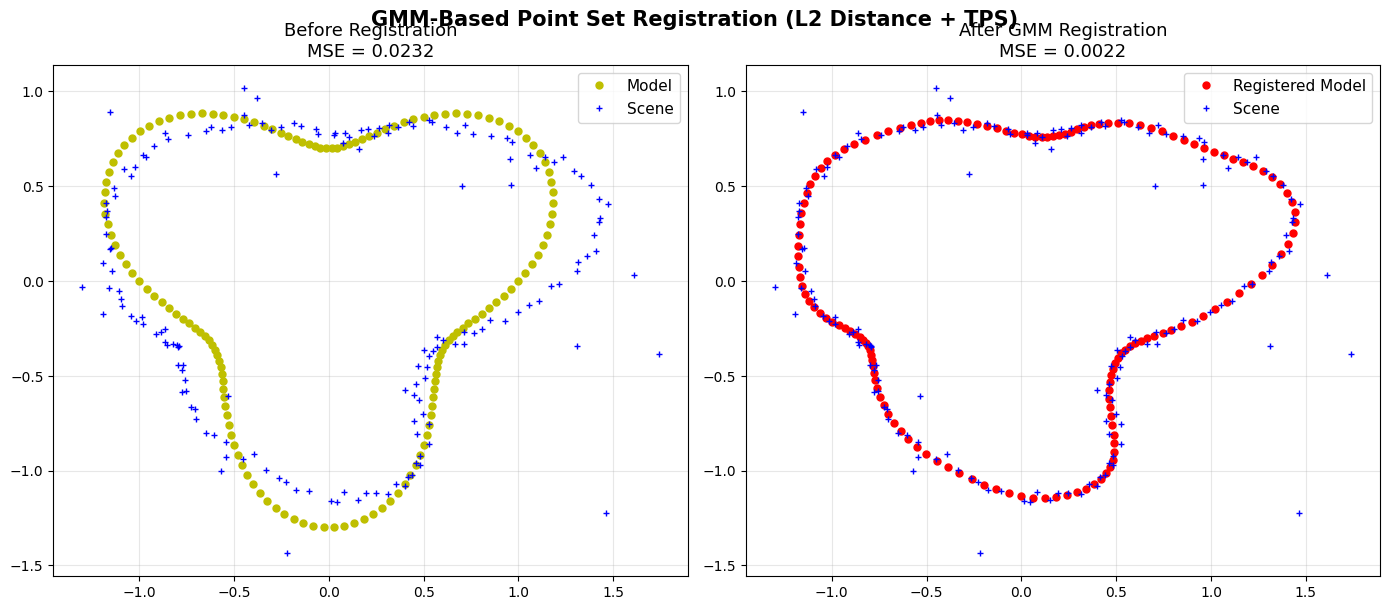

Saved: results/registration_result.png


In [8]:
# ============================================================
# Visualisation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before registration
axes[0].plot(model[:, 0], model[:, 1], 'yo', markersize=5, label='Model')
axes[0].plot(scene[:, 0], scene[:, 1], 'b+', markersize=5, label='Scene')
axes[0].set_title(f'Before Registration\nMSE = {mse_before:.4f}', fontsize=13)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# After registration
axes[1].plot(after_tps_final[:, 0], after_tps_final[:, 1], 'ro', markersize=5, label='Registered Model')
axes[1].plot(scene[:, 0], scene[:, 1], 'b+', markersize=5, label='Scene')
axes[1].set_title(f'After GMM Registration\nMSE = {mse:.4f}', fontsize=13)
axes[1].set_aspect('equal')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GMM-Based Point Set Registration (L2 Distance + TPS)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/registration_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/registration_result.png")